SECTION 1
Setup

(Import libraries and configure environment)

In [ ]:
import pandas as pd
import numpy as np

from tqdm import tqdm

from collections import defaultdict

from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

SECTION 2
Data Loading

(Load Netflix interactions for model development)

Objective

Create a structured user-movie-rating dataset for recommendation modeling.

In [ ]:
MAX_ROWS = 2_000_000

data = []

movie_id = None

rows_loaded = 0

with open(
    "combined_data_1.txt",
    "r"
) as f:

    for line in tqdm(f):

        line = line.strip()

        if line.endswith(":"):

            movie_id = int(
                line[:-1]
            )

        else:

            user_id, rating, date = (
                line.split(",")
            )

            data.append([
                int(user_id),
                movie_id,
                int(rating),
                pd.to_datetime(date)
            ])

            rows_loaded += 1

            if rows_loaded >= MAX_ROWS:
                break

2000360it [10:35, 3145.94it/s]


In [ ]:
ratings_df = pd.DataFrame(
    data,
    columns=[
        "user_id",
        "movie_id",
        "rating",
        "date"
    ]
)

ratings_df.head()

,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [ ]:
ratings_df.shape

(2000000, 4)

Observation

A representative subset of interactions is used for model development and experimentation.

SECTION 3
Random Split

(Randomly hold out interactions for evaluation)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    ratings_df,
    test_size=0.2,
    random_state=42
)

print(
    train_df.shape,
    test_df.shape
)

(1600000, 4) (400000, 4)


SECTION 4
Evaluation Functions

(Prepare RMSE metric)

In [ ]:
def rmse(
    actual,
    predicted
):

    return np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

SECTION 5
Model 1
Item-Based Collaborative Filtering

(Recommend movies using item similarity)

Can item similarity be used to predict user ratings?

In [ ]:
!pip install scikit-surprise -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.7 MB/s eta 0:00:00


In [ ]:
from surprise import Dataset
from surprise import Reader
from surprise import KNNBasic

In [ ]:
reader = Reader(
    rating_scale=(1,5)
)

surprise_data = Dataset.load_from_df(
    train_df[
        [
            "user_id",
            "movie_id",
            "rating"
        ]
    ],
    reader
)

In [ ]:
trainset = (
    surprise_data
    .build_full_trainset()
)

sim_options = {
    "name": "cosine",
    "user_based": False
}

item_cf = KNNBasic(
    sim_options=sim_options
)

item_cf.fit(
    trainset
)

Computing the cosine similarity matrix...
Done computing similarity matrix.


SECTION 6
Model 1 Evaluation

(Measure prediction accuracy)

In [ ]:
predictions = []

for row in tqdm(
    test_df.itertuples(),
    total=len(test_df)
):

    pred = item_cf.predict(
        row.user_id,
        row.movie_id
    )

    predictions.append(
        pred.est
    )

100%|██████████| 400000/400000 [00:12<00:00, 33137.35it/s]


In [ ]:
item_rmse = rmse(
    test_df["rating"],
    predictions
)

print(
    "Item CF RMSE:",
    round(
        item_rmse,
        4
    )
)

Item CF RMSE: 1.0881


SECTION 7
SVD Model

(Learning latent user and item factors)

In [ ]:
from surprise import SVD

In [ ]:
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

In [ ]:
svd_model.fit(trainset)

SECTION 8
SVD Evaluation

(Measure rating prediction accuracy)

In [ ]:
svd_predictions = []

for row in tqdm(
    test_df.itertuples(),
    total=len(test_df)
):

    pred = svd_model.predict(
        row.user_id,
        row.movie_id
    )

    svd_predictions.append(
        pred.est
    )

100%|██████████| 400000/400000 [00:03<00:00, 104519.21it/s]


In [ ]:
svd_rmse = rmse(
    test_df["rating"],
    svd_predictions
)

print(
    "SVD RMSE:",
    round(
        svd_rmse,
        4
    )
)

SVD RMSE: 0.9855


SECTION 9
Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Item-CF",
        "SVD"
    ],

    "RMSE": [
        item_rmse,
        svd_rmse
    ]
})

comparison

,Model,RMSE
0,Item-CF,1.088091
1,SVD,0.985481


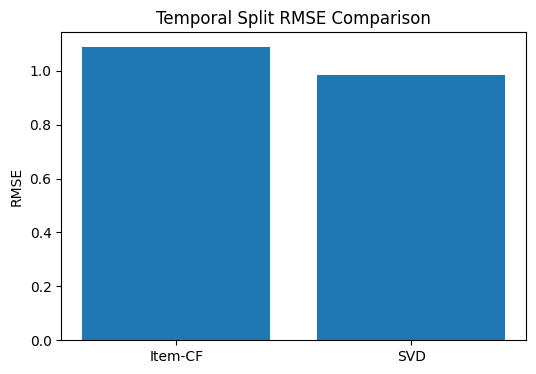

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title(
    "Temporal Split RMSE Comparison"
)

plt.ylabel(
    "RMSE"
)

plt.show()